In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Setting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('../data/cleaned/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,Tuesday


# RFM Analysis
RFM Analysis mengukur 3 dimensi dari perilaku pelanggan:

- Recency   → Seberapa baru pelanggan bertransaksi? (hari sejak transaksi terakhir)
- Frequency → Seberapa sering pelanggan bertransaksi? (jumlah invoice unik)
- Monetary  → Seberapa besar nilai transaksi? (total revenue per customer)

In [ ]:
# Tentukan reference date (1 hari setelah transaksi terakhir)
reference_date = df['InvoiceDate'].max() + timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Hitung RFM per customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"RFM Table Shape: {rfm.shape}")
print(f"Statistik RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Reference date: 2011-12-10

RFM Table Shape: (5878, 4)

Statistik RFM:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


In [3]:
# Beri RFM score 1-5 (5 = terbaik)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, 
                          labels=[5, 4, 3, 2, 1])  # Recency rendah = score tinggi
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, 
                          labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, 
                          labels=[1, 2, 3, 4, 5])

# Gabungkan menjadi RFM Score string
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

print("RFM Score distribution:")
print(rfm['RFM_Score'].value_counts().head(10))

RFM Score distribution:
RFM_Score
555    469
111    317
455    248
121    172
211    165
344    164
112    152
444    147
122    135
544    131
Name: count, dtype: int64


In [ ]:
# Segmentasi pelanggan dari nilai RFM

def rfm_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    elif r <= 2 and f <= 2 and m <= 2: 
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print("Segment Distribution:")
print(rfm['Segment'].value_counts())
print(f"Total customers: {len(rfm)}")

Segment Distribution:
Segment
Champions              1297
Loyal Customers        1138
Hibernating             811
Need Attention          702
At Risk                 616
Lost                    513
New Customers           443
Potential Loyalists     358
Name: count, dtype: int64

Total customers: 5878


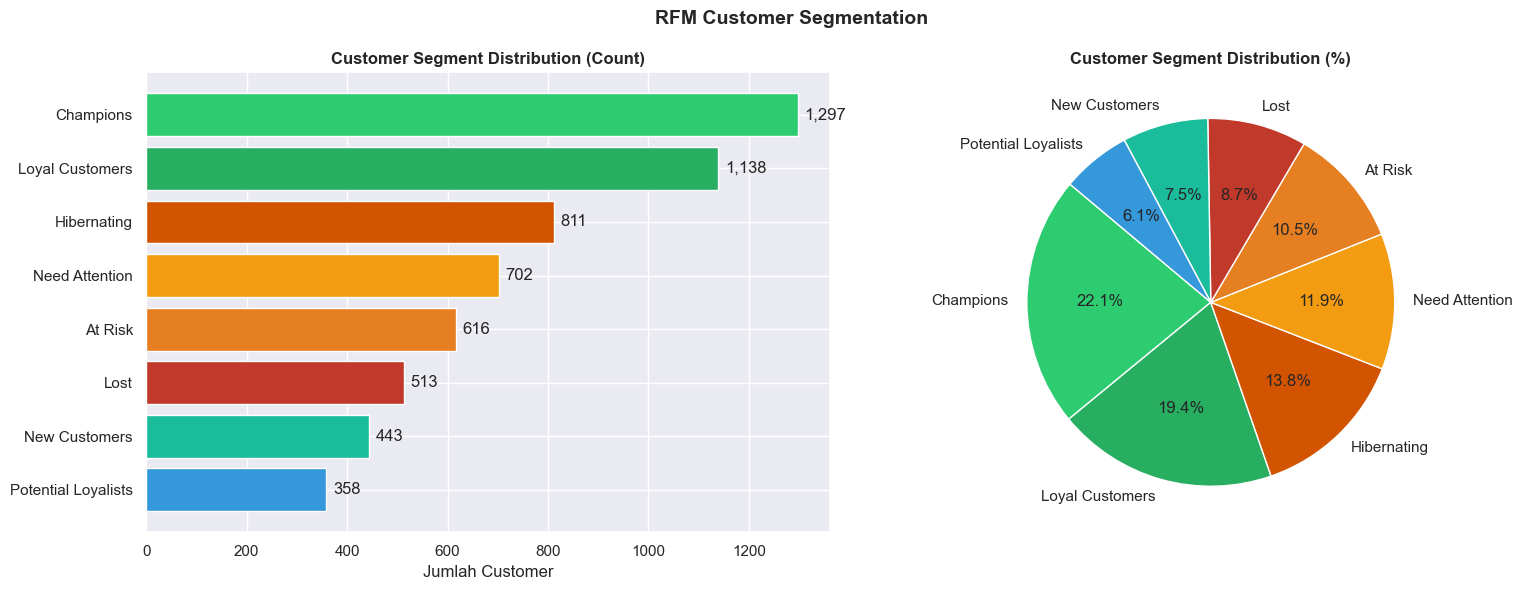

In [5]:
# Visualisasi segmen

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Warna per segmen
color_map = {
    'Champions'          : '#2ecc71',
    'Loyal Customers'    : '#27ae60',
    'Potential Loyalists': '#3498db',
    'New Customers'      : '#1abc9c',
    'Need Attention'     : '#f39c12',
    'Hibernating'        : '#d35400',
    'At Risk'            : '#e67e22',
    'Cannot Lose Them'   : '#e74c3c',
    'Lost'               : '#c0392b'
}
colors = [color_map.get(s, 'steelblue') for s in segment_counts['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].barh(segment_counts['Segment'], 
                    segment_counts['Count'], color=colors)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=5)
axes[0].set_title('Customer Segment Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Jumlah Customer')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(segment_counts['Count'], labels=segment_counts['Segment'],
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Customer Segment Distribution (%)', fontweight='bold')

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Summary per segmen RFM

segment_summary = rfm.groupby('Segment').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency', 'mean'),
    Avg_Frequency   = ('Frequency', 'mean'),
    Avg_Monetary    = ('Monetary', 'mean')
).round(2).reset_index()

segment_summary = segment_summary.sort_values('Avg_Monetary', ascending=False)

print(segment_summary.to_string(index=False))

            Segment  Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
          Champions             1297        19.96          17.11       9143.86
            At Risk              616       359.51           5.62       2444.23
    Loyal Customers             1138        73.38           5.95       2255.40
      New Customers              443        28.11           1.46        885.48
     Need Attention              702       270.46           1.96        630.14
Potential Loyalists              358        79.72           2.70        591.26
               Lost              513       568.23           1.00        344.32
        Hibernating              811       407.17           1.29        271.26


In [ ]:
# Simpan hasil RFM

rfm.to_csv('../data/cleaned/rfm_segments.csv', index=False)
print("rfm_segments.csv berhasil disimpan!")
print(f"RFM Columns: {list(rfm.columns)}")
print(f"Total customers: {len(rfm):,}")

✅ rfm_segments.csv berhasil disimpan!

RFM Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']
Total customers: 5,878


# K-Means Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

# Fitur RFM
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Log Transformation
rfm_features_log = rfm_features.copy()
rfm_features_log['Recency']   = np.log1p(rfm_features['Recency'])
rfm_features_log['Frequency'] = np.log1p(rfm_features['Frequency'])
rfm_features_log['Monetary']  = np.log1p(rfm_features['Monetary'])

# Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Sebelum transformasi:")
print(rfm_features.describe().round(2))
print("Setelah Log Transform + Scaling:")
print(rfm_scaled.describe().round(2))

Sebelum transformasi:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04

Setelah Log Transform + Scaling:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean     -0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.41      -1.06     -3.93
25%      -0.74      -1.06     -0.71
50%       0.08      -0.20     -0.04
75%       0.95       0.65      0.65
max       1.38       5.48      4.66


## Catatan: Mengapa Log Transformation?

Sebelum melakukan clustering, data RFM perlu dipersiapkan terlebih dahulu
karena dua alasan utama:

### 1. Distribusi Right-Skewed
Data RFM kita memiliki distribusi yang sangat right-skewed:
- Sebagian besar pelanggan memiliki Frequency & Monetary yang rendah
- Segelintir wholesaler besar memiliki nilai yang sangat ekstrem
- Contoh: Monetary max = £580.987, jauh di atas mean £2.955

Log Transformation mengompres nilai-nilai ekstrem secara proporsional
sehingga distribusi menjadi lebih simetris tanpa membuang data apapun.

### 2. Sensitivitas K-Means terhadap Outlier
K-Means bekerja berdasarkan jarak Euclidean — outlier ekstrem dapat
menarik centroid cluster ke arahnya dan menghasilkan cluster yang
tidak representatif.

### Mengapa Log Transformation, bukan yang lain?
| Metode | Kelemahan untuk kasus ini |
|---|---|
| Drop outlier | Data valid wholesaler ikut terbuang |
| Winsorizing | Nilai dipaksa ke batas tertentu, kurang natural |
| RobustScaler | Outlier masih ada, hanya scaling yang berubah |
| **Log Transformation** | Memperbaiki distribusi secara proporsional, tidak ada data yang dibuang atau dipaksa |

### Formula
`log1p(x) = log(1 + x)` → menambahkan 1 untuk menghindari log(0)
yang akan terjadi jika ada nilai 0 di data.

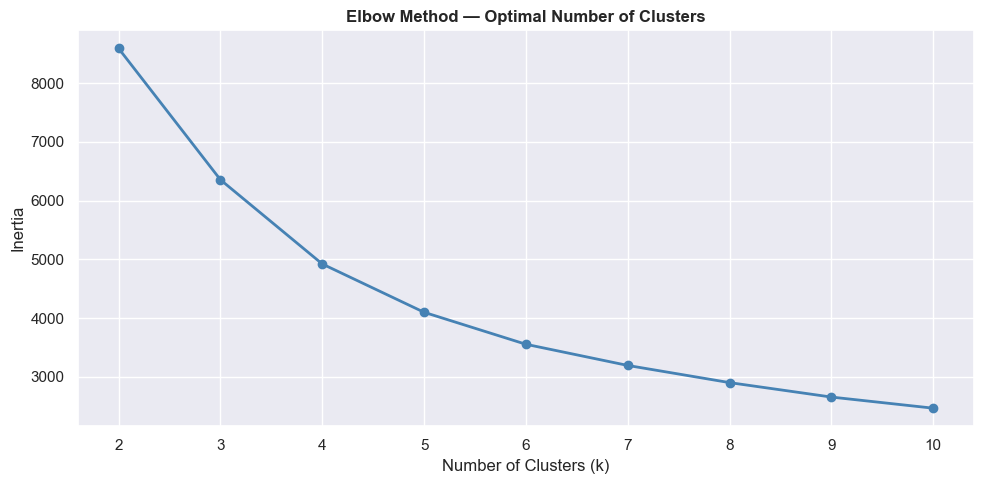

Inertia per k:
  k=2: 8588.99
  k=3: 6354.34
  k=4: 4921.23
  k=5: 4099.11
  k=6: 3554.70
  k=7: 3194.50
  k=8: 2902.43
  k=9: 2656.56
  k=10: 2467.38


In [9]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/09_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("Inertia per k:")
for k, i in zip(k_range, inertia):
    print(f"  k={k}: {i:.2f}")

Keputusannya adalah k=4 menjadi pilihan terbaik dengan alasan:

- Titik di mana penurunan inertia mulai melambat secara konsisten
- 4 cluster menghasilkan profil bisnis yang mudah diinterpretasikan.
- Tidak terlalu banyak sehingga mudah dijelaskan ke stakeholder.

In [ ]:
# Fit K-Means dengan k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"Cluster Centers (scaled):")
centers = pd.DataFrame(kmeans.cluster_centers_, 
                        columns=['Recency', 'Frequency', 'Monetary'])
print(centers.round(3))

Cluster Distribution:
Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

Cluster Centers (scaled):
   Recency  Frequency  Monetary
0    0.871     -0.881    -0.944
1   -0.889     -0.286    -0.218
2   -1.078      1.498     1.329
3    0.470      0.206     0.372


In [11]:
# Profil cluster berdasarkan nilai RFM asli (sebelum transformasi)
cluster_profile = rfm.groupby('Cluster').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency', 'mean'),
    Avg_Frequency   = ('Frequency', 'mean'),
    Avg_Monetary    = ('Monetary', 'mean')
).round(2).reset_index()

print("Cluster Profile (nilai RFM asli):")
print(cluster_profile.to_string(index=False))

Cluster Profile (nilai RFM asli):
 Cluster  Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
       0             1973       394.95           1.38        317.08
       1             1250        28.30           3.05        857.49
       2             1196        27.71          19.28      10731.16
       3             1459       230.07           5.06       1948.50


In [12]:
# Beri label bisnis pada cluster
cluster_labels = {
    0: 'Inactive',
    1: 'Promising',
    2: 'High Value',
    3: 'At Risk'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print("Cluster Label Distribution:")
print(rfm['Cluster_Label'].value_counts())

Cluster Label Distribution:
Cluster_Label
Inactive      1973
At Risk       1459
Promising     1250
High Value    1196
Name: count, dtype: int64


Explained Variance Ratio: [0.764 0.187]
Total Variance Explained: 95.1%


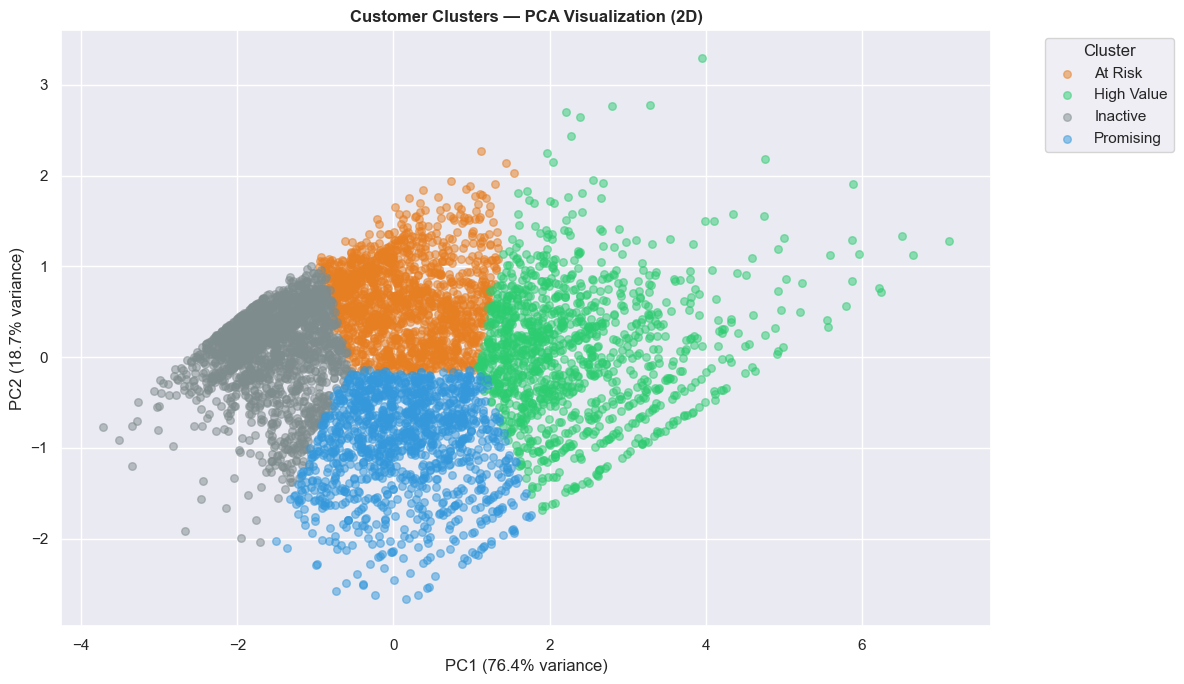

In [13]:
from sklearn.decomposition import PCA

# Reduksi dimensi ke 2D dengan PCA
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.1%}")

# DataFrame untuk plotting
pca_df = pd.DataFrame({
    'PC1'          : rfm_pca[:, 0],
    'PC2'          : rfm_pca[:, 1],
    'Cluster'      : rfm['Cluster'],
    'Cluster_Label': rfm['Cluster_Label']
})

# Warna per cluster
cluster_colors = {
    'High Value' : '#2ecc71',
    'Promising'  : '#3498db',
    'At Risk'    : '#e67e22',
    'Inactive'   : '#7f8c8d'
}

fig, ax = plt.subplots(figsize=(12, 7))
for label, group in pca_df.groupby('Cluster_Label'):
    ax.scatter(group['PC1'], group['PC2'],
               label=label, alpha=0.5, s=30,
               color=cluster_colors[label])

ax.set_title('Customer Clusters — PCA Visualization (2D)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/10_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

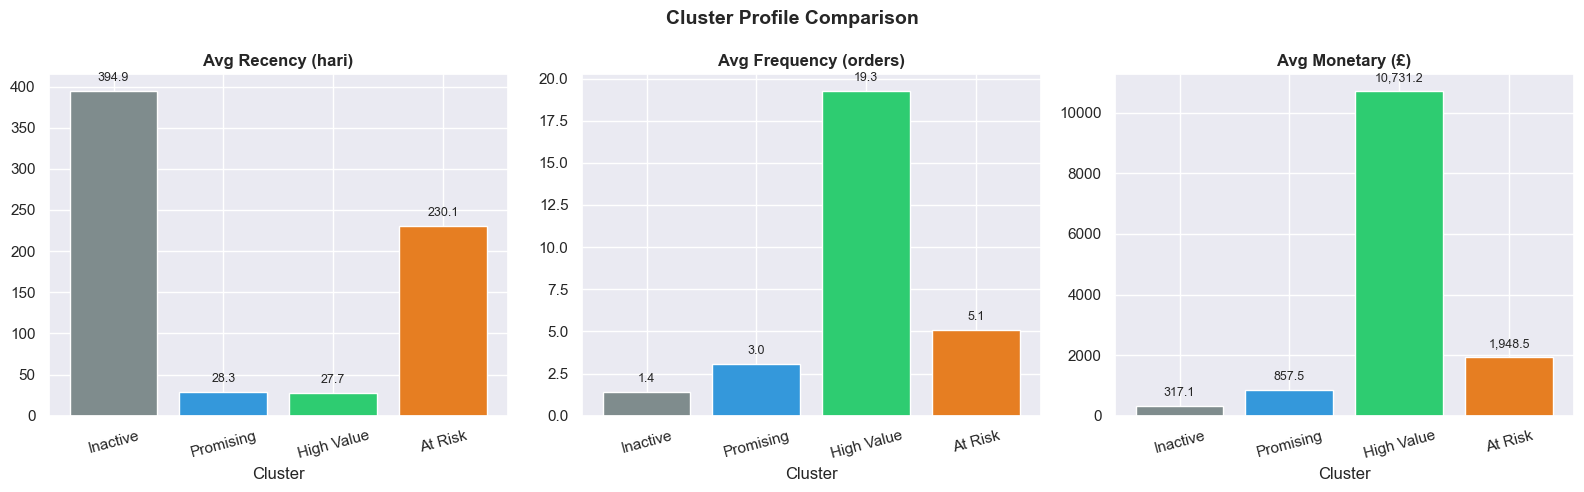

In [14]:
# Visualisasi profil cluster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
titles  = ['Avg Recency (hari)', 'Avg Frequency (orders)', 'Avg Monetary (£)']
colors  = [cluster_colors[cluster_labels[i]] for i in range(4)]
labels  = [cluster_labels[i] for i in range(4)]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(labels, cluster_profile[metric], color=colors)
    ax.bar_label(bars, fmt='{:,.1f}', padding=5, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Cluster Profile Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/11_cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Gabungkan cluster label ke rfm dataframe
rfm.to_csv('../data/cleaned/rfm_segments.csv', index=False)

# Simpan cluster profile
cluster_profile['Cluster_Label'] = cluster_profile['Cluster'].map(cluster_labels)
cluster_profile.to_csv('../data/cleaned/cluster_profile.csv', index=False)

print("rfm_segments.csv diperbarui dengan kolom Cluster & Cluster_Label!")
print("cluster_profile.csv berhasil disimpan!")
print(f"Kolom rfm sekarang: {list(rfm.columns)}")

✅ rfm_segments.csv diperbarui dengan kolom Cluster & Cluster_Label!
✅ cluster_profile.csv berhasil disimpan!

Kolom rfm sekarang: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment', 'Cluster', 'Cluster_Label']


In [16]:
# Opsional: plot clustering 3D
import plotly.express as px

# Reduksi dimensi ke 3D dengan PCA
pca_3d = PCA(n_components=3, random_state=42)
rfm_pca_3d = pca_3d.fit_transform(rfm_scaled)

print(f"Explained Variance Ratio: {pca_3d.explained_variance_ratio_.round(3)}")
print(f"Total Variance Explained: {pca_3d.explained_variance_ratio_.sum():.1%}")

# DataFrame untuk plotting
pca_df_3d = pd.DataFrame({
    'PC1'          : rfm_pca_3d[:, 0],
    'PC2'          : rfm_pca_3d[:, 1],
    'PC3'          : rfm_pca_3d[:, 2],
    'Cluster_Label': rfm['Cluster_Label']
})

# Plot 3D interaktif dengan Plotly
fig = px.scatter_3d(
    pca_df_3d,
    x='PC1', y='PC2', z='PC3',
    color='Cluster_Label',
    color_discrete_map=cluster_colors,
    title='Customer Clusters — PCA Visualization (3D)',
    labels={
        'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    },
    opacity=0.6,
    width=900,
    height=700
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(legend_title_text='Cluster')
fig.show()

Explained Variance Ratio: [0.764 0.187 0.049]
Total Variance Explained: 100.0%


# Cohort Analysis
Cohort Analysis mengelompokkan pelanggan berdasarkan bulan pertama mereka bertransaksi, lalu melacak berapa % dari mereka yang masih aktif di bulan-bulan berikutnya. Hasilnya divisualisasikan sebagai heatmap, dimana semakin gelap warnanya, semakin tinggi retention rate-nya.

In [ ]:
# Ambil bulan pertama transaksi per customer (cohort month)
df_cohort = df[['Customer ID', 'InvoiceDate']].copy()

# Cohort month = bulan pertama transaksi
df_cohort['Cohort_Month'] = df_cohort.groupby('Customer ID')['InvoiceDate'] \
                                      .transform('min').dt.to_period('M')

# Transaction month = bulan transaksi saat ini
df_cohort['Transaction_Month'] = df_cohort['InvoiceDate'].dt.to_period('M')

# Cohort Index = jarak bulan dari cohort month
df_cohort['Cohort_Index'] = (df_cohort['Transaction_Month'] - 
                              df_cohort['Cohort_Month']).apply(lambda x: x.n)

print(f"Shape: {df_cohort.shape}")
print(f"Sample data:")
print(df_cohort.head(10))

Shape: (779425, 5)

Sample data:
   Customer ID         InvoiceDate Cohort_Month Transaction_Month  \
0        13085 2009-12-01 07:45:00      2009-12           2009-12   
1        13085 2009-12-01 07:45:00      2009-12           2009-12   
2        13085 2009-12-01 07:45:00      2009-12           2009-12   
3        13085 2009-12-01 07:45:00      2009-12           2009-12   
4        13085 2009-12-01 07:45:00      2009-12           2009-12   
5        13085 2009-12-01 07:45:00      2009-12           2009-12   
6        13085 2009-12-01 07:45:00      2009-12           2009-12   
7        13085 2009-12-01 07:45:00      2009-12           2009-12   
8        13085 2009-12-01 07:46:00      2009-12           2009-12   
9        13085 2009-12-01 07:46:00      2009-12           2009-12   

   Cohort_Index  
0             0  
1             0  
2             0  
3             0  
4             0  
5             0  
6             0  
7             0  
8             0  
9             0  


In [18]:
# Hitung jumlah unique customer per cohort & cohort index
cohort_data = df_cohort.groupby(['Cohort_Month', 'Cohort_Index']) \
                        ['Customer ID'].nunique().reset_index()
cohort_data.columns = ['Cohort_Month', 'Cohort_Index', 'Total_Customers']

# Pivot ke matrix
cohort_matrix = cohort_data.pivot_table(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='Total_Customers'
)

print("Cohort Matrix (jumlah customer):")
print(cohort_matrix.iloc[:5, :6])

Cohort Matrix (jumlah customer):
Cohort_Index      0      1      2      3      4      5
Cohort_Month                                          
2009-12       955.0  337.0  319.0  406.0  363.0  343.0
2010-01       383.0   79.0  119.0  117.0  101.0  115.0
2010-02       374.0   89.0   84.0  109.0   92.0   75.0
2010-03       443.0   84.0  102.0  107.0  103.0   90.0
2010-04       294.0   57.0   57.0   48.0   54.0   66.0


In [19]:
# Hitung retention rate = jumlah customer bulan ke-N / jumlah customer bulan ke-0
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

print("Retention Matrix (%):")
print(retention_matrix.iloc[:5, :6])

Retention Matrix (%):
Cohort_Index      0     1     2     3     4     5
Cohort_Month                                     
2009-12       100.0  35.3  33.4  42.5  38.0  35.9
2010-01       100.0  20.6  31.1  30.5  26.4  30.0
2010-02       100.0  23.8  22.5  29.1  24.6  20.1
2010-03       100.0  19.0  23.0  24.2  23.3  20.3
2010-04       100.0  19.4  19.4  16.3  18.4  22.4


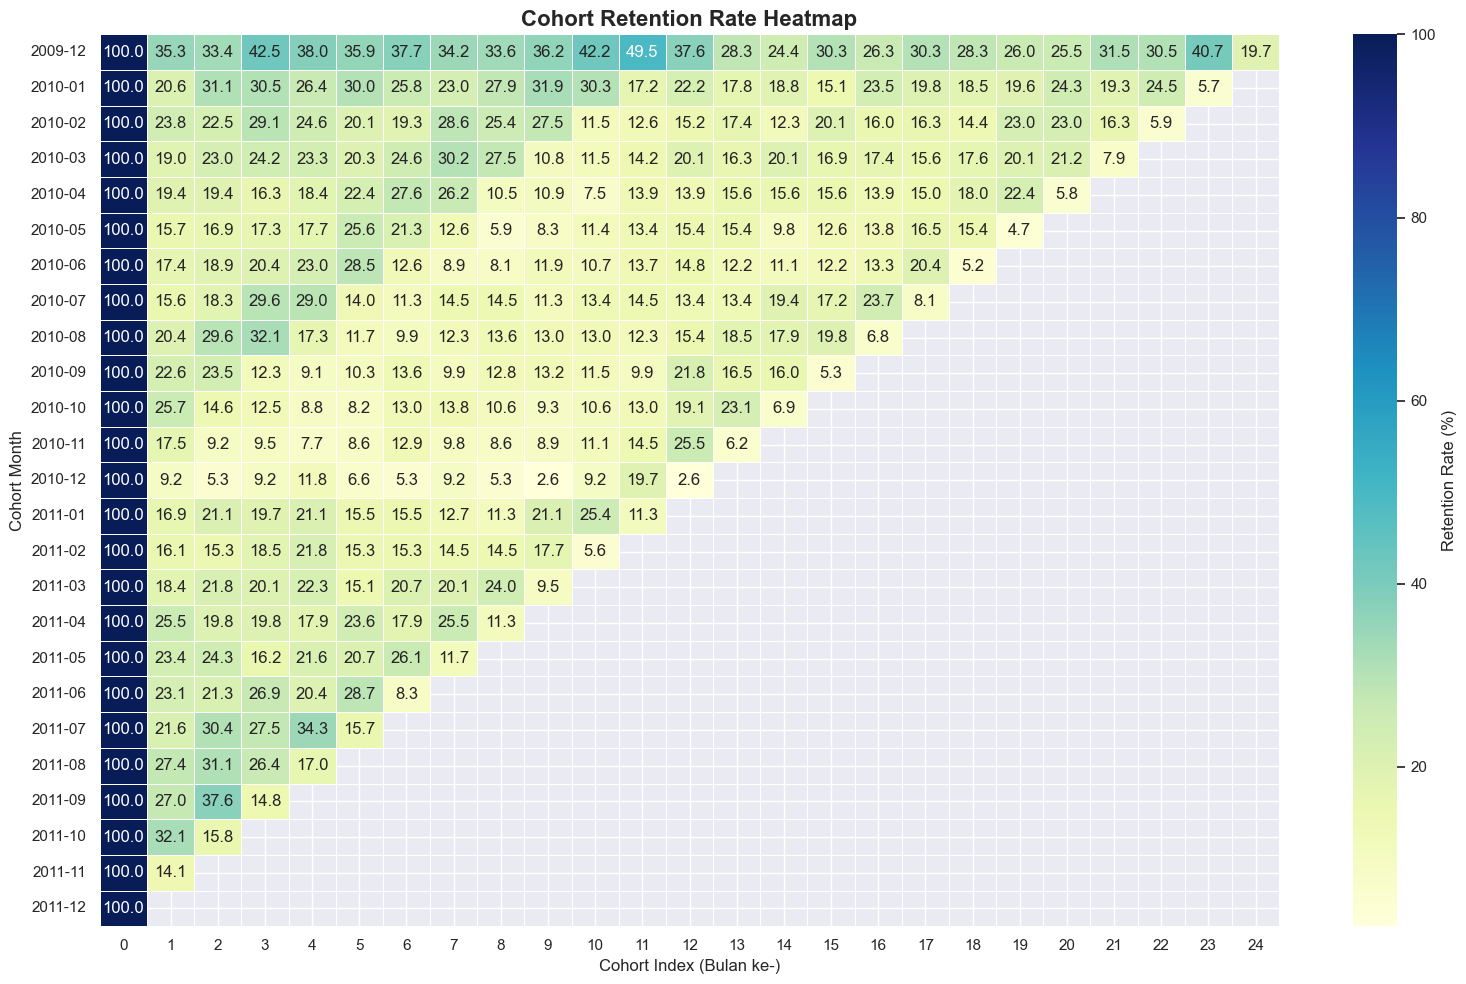

In [20]:
# Visualisasi cohort heatmap
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title('Cohort Retention Rate Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Cohort Index (Bulan ke-)')
ax.set_ylabel('Cohort Month')
ax.yaxis.set_tick_params(rotation=0)
plt.tight_layout()
plt.savefig('../reports/12_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Simpan hasil cohort analysiis
retention_matrix.to_csv('../data/cleaned/cohort_retention.csv')
print("cohort_retention.csv berhasil disimpan!")
print(f"Cohort Matrix Shape: {retention_matrix.shape}")
print(f"Total Cohorts: {len(retention_matrix)}")

✅ cohort_retention.csv berhasil disimpan!

Cohort Matrix Shape: (25, 25)
Total Cohorts: 25


In [ ]:
# Convert file cohort ke format long untuk keperluan dashboard
cohort = pd.read_csv('../data/cleaned/cohort_retention.csv', index_col=0)

# Convert wide → long
cohort_long = cohort.reset_index().melt(
    id_vars='Cohort_Month',
    var_name='Cohort_Index',
    value_name='Retention_Rate'
)

# Pastikan tipe data benar
cohort_long['Cohort_Index'] = cohort_long['Cohort_Index'].astype(int)
cohort_long['Retention_Rate'] = cohort_long['Retention_Rate'].astype(float)

# Hapus baris kosong (bagian segitiga kosong heatmap)
cohort_long = cohort_long.dropna(subset=['Retention_Rate'])

print(cohort_long.head(10))
print(f"Shape: {cohort_long.shape}")

# Simpan
cohort_long.to_csv('../data/cleaned/cohort_retention_long.csv', index=False)
print("cohort_retention_long.csv berhasil disimpan.")

  Cohort_Month  Cohort_Index  Retention_Rate
0      2009-12             0           100.0
1      2010-01             0           100.0
2      2010-02             0           100.0
3      2010-03             0           100.0
4      2010-04             0           100.0
5      2010-05             0           100.0
6      2010-06             0           100.0
7      2010-07             0           100.0
8      2010-08             0           100.0
9      2010-09             0           100.0

Shape: (325, 3)
✅ cohort_retention_long.csv berhasil disimpan!
